# Data Engineering Project Part 3
## StopEvent Pipeline, Data Analysis, and Visualization

This notebook documents your team's implementation of Part 3 of the Data Engineering project.
You will use this notebook to record your programs, configurations, evidence of a working
pipeline, database queries, map visualizations, and written reflections.

**Instructions:** Work through each section in order. Fill in every cell marked with
`[YOUR INPUT HERE]` or `[PASTE HERE]`. Do not delete any section headings or instruction cells.

Submit your completed notebook once you have three successful days of end-to-end pipeline runs
recorded in Section 8.

---

### Team Information

Fill in the cell below with your team details.

**Team Members** (list each member's name and @pdx.edu email, one per line):

Vinodh Raju - vinodh@pdx.edu

Neha Marlady - nmarlady@pdx.edu


**GCP Project ID:**

cs536-data-engineering

**Vehicle Group Name:**

Shazam

---
## Table of Contents

1. [Review Parts 1 and 2 — Preview Part 3](#1-review-parts-1-and-2--preview-part-3)
2. [Understand the StopEvent Data](#2-understand-the-stopevent-data)
3. [Add Pub/Sub Items for StopEvent Data](#3-add-pubsub-items-for-stopevent-data)
4. [Modify Your Publisher VM](#4-modify-your-publisher-vm)
    - 4.1 [se_publisher.py](#41-se_publisherpy)
    - 4.2 [Updated Crontab](#42-updated-crontab)
5. [Modify Your Backup VM](#5-modify-your-backup-vm)
    - 5.1 [se_backup.py](#51-se_backuppy)
    - 5.2 [System Service Configuration](#52-system-service-configuration)
6. [Modify Your Analysis VM](#6-modify-your-analysis-vm)
    - 6.1 [StopEvent Table Schema](#61-stopevent-table-schema)
    - 6.2 [se_analysis.py](#62-se_analysispy)
    - 6.3 [System Service Configuration](#63-system-service-configuration)
7. [Run Both Pipelines Daily and Debug Issues](#7-run-both-pipelines-daily-and-debug-issues)
    - 7.1 [Monitor GCP Credits](#71-monitor-gcp-credits)
    - 7.2 [Monitor Storage Space](#72-monitor-storage-space)
8. [Pipeline Run Statistics](#8-pipeline-run-statistics)
9. [Data Analysis](#9-data-analysis)
    - 9.1 [Connect to the Database](#91-connect-to-the-database)
    - 9.2 [Example Analysis Query](#92-example-analysis-query)
    - 9.3 [Your Analysis Queries](#93-your-analysis-queries)
    - 9.4 [Additional Queries of Your Choice](#94-additional-queries-of-your-choice)
10. [Data Visualization](#10-data-visualization)
    - 10.1 [Example Visualization — Speed Along a Single Trip](#101-example-visualization--speed-along-a-single-trip)
    - 10.2 [Example Visualization — Breadcrumbs and Stops for a High-Boarding Trip](#102-example-visualization--breadcrumbs-and-stops-for-a-high-boarding-trip)
    - 10.3 [Your Required Folium Visualizations](#103-your-required-folium-visualizations)
    - 10.4 [Your Additional Visualizations of Your Choice](#104-your-additional-visualizations-of-your-choice)
11. [Reflections](#11-reflections)

---


## 1. Review Parts 1 and 2 — Preview Part 3

### Congratulations!

By now you have a working, end-to-end data pipeline. Your pipeline runs daily and processes
BreadCrumb data from the TriMet bus fleet. Keep your automated pipeline running every day —
it should be gathering, transporting, and backing up BreadCrumb data automatically.

### What you built in Parts 1 and 2

- **Part 1** — You implemented and automated an initial data pipeline for BreadCrumb data.
  Three programs run daily: `publisher.py` on the Publisher VM gathers breadcrumbs from the
  BusData API and publishes them to `bc_topic`; `analysis.py` on the Analysis VM subscribes
  to `bc_topic` via `analysis_sub` and processes incoming records; `backup.py` on the Backup
  VM subscribes via `backup_sub` and archives records to daily compressed files.

- **Part 2** — You extended `analysis.py` to validate, transform, and load BreadCrumb records
  into a PostgreSQL database running on your Analysis VM. You also used Colab to query and
  visualize the stored data using Folium maps.

### What you will build in Part 3

In Part 3 you will implement a second, parallel data pipeline for **StopEvent** data while
continuing to run the BreadCrumb pipeline. Specifically you will:

1. Create new GCP Pub/Sub resources for StopEvent data.
2. Write `se_publisher.py` to gather and publish StopEvent records.
3. Write `se_backup.py` to subscribe to and archive StopEvent records.
4. Write `se_analysis.py` to validate, transform, and load StopEvent records into PostgreSQL.
5. Run both pipelines automatically every day.
6. Use Colab, Python, SQL, and Folium to analyze and visualize your combined dataset,
   including queries and visualizations that join the BreadCrumb and StopEvent tables.

---


## 2. Understand the StopEvent Data

Before writing any code, you need to understand what StopEvent records look like and what
each field means.

### 2.1 Examine Sample StopEvent Records

Use the cell below to fetch sample StopEvent records from the BusData API for one of the
vehicles in your group. The API returns an HTML page containing one table per trip, with one
row per stop event.

Replace `<YOUR_VEHICLE_NUM>` with a vehicle number from your assigned vehicle group.


In [4]:
import requests

vehicle_num = "3535"   # replace with a vehicle number from your group
url = f"https://busdata.cs.pdx.edu/api/getStopEvents?vehicle_num={vehicle_num}"

response = requests.get(url)
print(f"HTTP status: {response.status_code}")
print()
# Print the first 3000 characters of the HTML response to see its structure
print(response.text[:3000])


HTTP status: 200

<!DOCTYPE html><head><title>TriMet Stop Events</title></head><body><h1>Trimet CAD/AVL stop data for 2023-01-25</h1><h2>Stop events for PDX_TRIP 244881488</h2><table><tr><th>vehicle_number</th><th>leave_time</th><th>train</th><th>route_number</th><th>direction</th><th>service_key</th><th>trip_number</th><th>stop_time</th><th>arrive_time</th><th>dwell</th><th>location_id</th><th>door</th><th>lift</th><th>ons</th><th>offs</th><th>estimated_load</th><th>maximum_speed</th><th>train_mileage</th><th>pattern_distance</th><th>location_distance</th><th>x_coordinate</th><th>y_coordinate</th><th>data_source</th><th>schedule_status</th></tr><tr><td>3535</td><td>41332</td><td>7706</td><td>77</td><td>0</td><td>W</td><td>1130</td><td>41280</td><td>41332</td><td>0</td><td>8484</td><td>2</td><td>0</td><td>1</td><td>0</td><td>1</td><td>1</td><td>6.22</td><td>0</td><td>0</td><td>7636688.89</td><td>689620.12</td><td>2</td><td>5</td></tr><tr><td>3535</td><td>41354</td><td>7706</td><td>77</

### 2.2 StopEvent Field Descriptions

The TriMet documentation (Section 3.2, *Bus Stop Event Data*) describes each field in a
StopEvent record. Review the documentation at:

> https://portal.its.pdx.edu/static/files/fhwa/Transit%20Data%20Documentation.pdf

Then complete the table below with a description of each field in your own words.
Focus on how each field is measured or produced, its units, and how it relates to other fields.


| Field | Type | Your Description |
|---|---|---|
| `vehicle_number` | integer | Unique identifier for the physical bus vehicle. Links to `vehicle_id` in the breadcrumb table, allowing us to join stop events with GPS data for the same vehicle. |
| `leave_time` | integer | Time the vehicle departed the stop, measured in seconds elapsed since midnight. Used to calculate how long the bus was delayed at each stop. |
| `train` | integer | Block number representing the vehicle's daily assignment. A block is a sequence of trips assigned to one vehicle for the day. |
| `route_number` | integer | TriMet route number identifying which bus line this vehicle is operating on (e.g. Route 57, Route 72). |
| `direction` | integer | Direction of travel along the route. Typically 0 = outbound (away from downtown) and 1 = inbound (toward downtown). |
| `service_key` | character(1) | Type of service day: W = Weekday, S = Saturday, U = Sunday/Holiday. Determines which schedule applies. |
| `trip_number` | integer | Unique identifier for a single trip. Links to `trip_id` in the breadcrumb table, allowing joins between stop events and GPS breadcrumbs for the same trip. |
| `stop_time` | integer | Scheduled arrival time at the stop in seconds since midnight. Used to calculate on-time performance by comparing with arrive_time. |
| `arrive_time` | integer | Actual arrival time at the stop in seconds since midnight. Compared with stop_time to determine if the bus was early, on time, or late. |
| `dwell` | integer | Number of seconds the vehicle spent at the stop between arriving and departing. Longer dwell times indicate more passenger activity. |
| `location_id` | integer | Unique identifier for the bus stop location. Can be used to look up stop name, coordinates, and other stop attributes. |
| `door` | integer | Indicates whether the door was opened at this stop. 0 = doors closed (no passengers), 2 = doors opened. |
| `lift` | integer | Indicates whether the wheelchair lift was deployed. 0 = lift not used, 1 = lift used for accessibility boarding or alighting. |
| `ons` | integer | Number of passengers who boarded the bus at this stop. Used to analyze ridership patterns and identify high-demand stops. |
| `offs` | integer | Number of passengers who alighted (exited) the bus at this stop. Combined with ons gives total passenger activity at each stop. |
| `estimated_load` | integer | Estimated number of passengers on board after the stop. Calculated as previous load + ons - offs. Useful for identifying crowded trips. |
| `maximum_speed` | integer | Maximum speed in miles per hour recorded between the previous stop and this stop. Can identify speeding or unusual driving behavior. |
| `train_mileage` | float | Cumulative odometer reading in miles at the time of this stop event. Tracks total distance traveled by the vehicle. |
| `pattern_distance` | float | Distance in feet from the beginning of the route pattern to this stop. Used to order stops along the route. |
| `location_distance` | float | Distance in feet from the beginning of the location segment to this stop. Used for precise stop positioning within a segment. |
| `x_coordinate` | float | Oregon State Plane X coordinate of the stop location in feet. Can be converted to longitude for mapping purposes. |
| `y_coordinate` | float | Oregon State Plane Y coordinate of the stop location in feet. Can be converted to latitude for mapping purposes. |
| `data_source` | integer | Indicates the source of the data. 2 = AVL (Automatic Vehicle Location) system, which is the primary GPS-based data source. |
| `schedule_status` | integer | On-time performance status. 2 = late, 5 = on time. Used to analyze schedule adherence across routes and stops. |

### 2.3 Knowledge Check

Answer the following questions to demonstrate your understanding of the StopEvent data.
Write your answers in the cells below each question.

**Question 1:** A stop event record is created whenever a vehicle passes a scheduled stop.
The `arrive_time` field can reflect two different situations depending on whether or not the
bus door opens at that stop. Describe both situations and explain precisely what `arrive_time`
represents in each case. How does `dwell` relate to `arrive_time` and `leave_time`?

**Your answer:**

arrive_time works differently depending on whether the bus opens its doors or not.

When the bus opens its doors, arrive_time is when the bus actually
stopped at the stop. Passengers board and alight, then the bus leaves. The dwell time (leave_time - arrive_time) shows how long the bus waited.

When the bus does not open its doors, arrive_time is when the bus
passed through the stop location without stopping. In this case
dwell = 0 because the bus did not wait at all.

So dwell always equals leave_time minus arrive_time. A dwell of 0
means no passengers were served. A larger dwell means more time was
spent at the stop.

---

**Question 2:** The `x_coordinate` and `y_coordinate` fields do not use the familiar
WGS 84 latitude/longitude coordinate system. What coordinate system do they use, what
are the units, and why might TriMet use this system rather than GPS lat/lon for stop
locations? How will you convert these coordinates to GPS latitude and longitude in your
`se_analysis.py` program?

**Your answer:**

The x_coordinate and y_coordinate use the Oregon State Plane coordinate system measured in feet. TriMet uses this instead of GPS lat/lon because it is more accurate for local Oregon measurements and works better with Oregon's GIS systems.

To convert to GPS coordinates in se_analysis.py we will use the pyproj library to transform from Oregon State Plane (EPSG:2269) to WGS 84 lat/lon (EPSG:4326) so we can plot stops on a Folium map.

---


## 3. Add Pub/Sub Items for StopEvent Data

You will create dedicated GCP Pub/Sub resources for the StopEvent pipeline. These are
separate from the BreadCrumb Pub/Sub resources you created in Part 1.

### 3.1 Create `se_topic`

In the GCP console, navigate to **Pub/Sub > Topics** and create a new topic named
`se_topic`. Configure it similarly to the `bc_topic` you created in Part 1
(default settings are fine; retain the default subscription if prompted).

Paste a screenshot showing `se_topic` in the topic list below.

**Screenshot — se_topic created:**

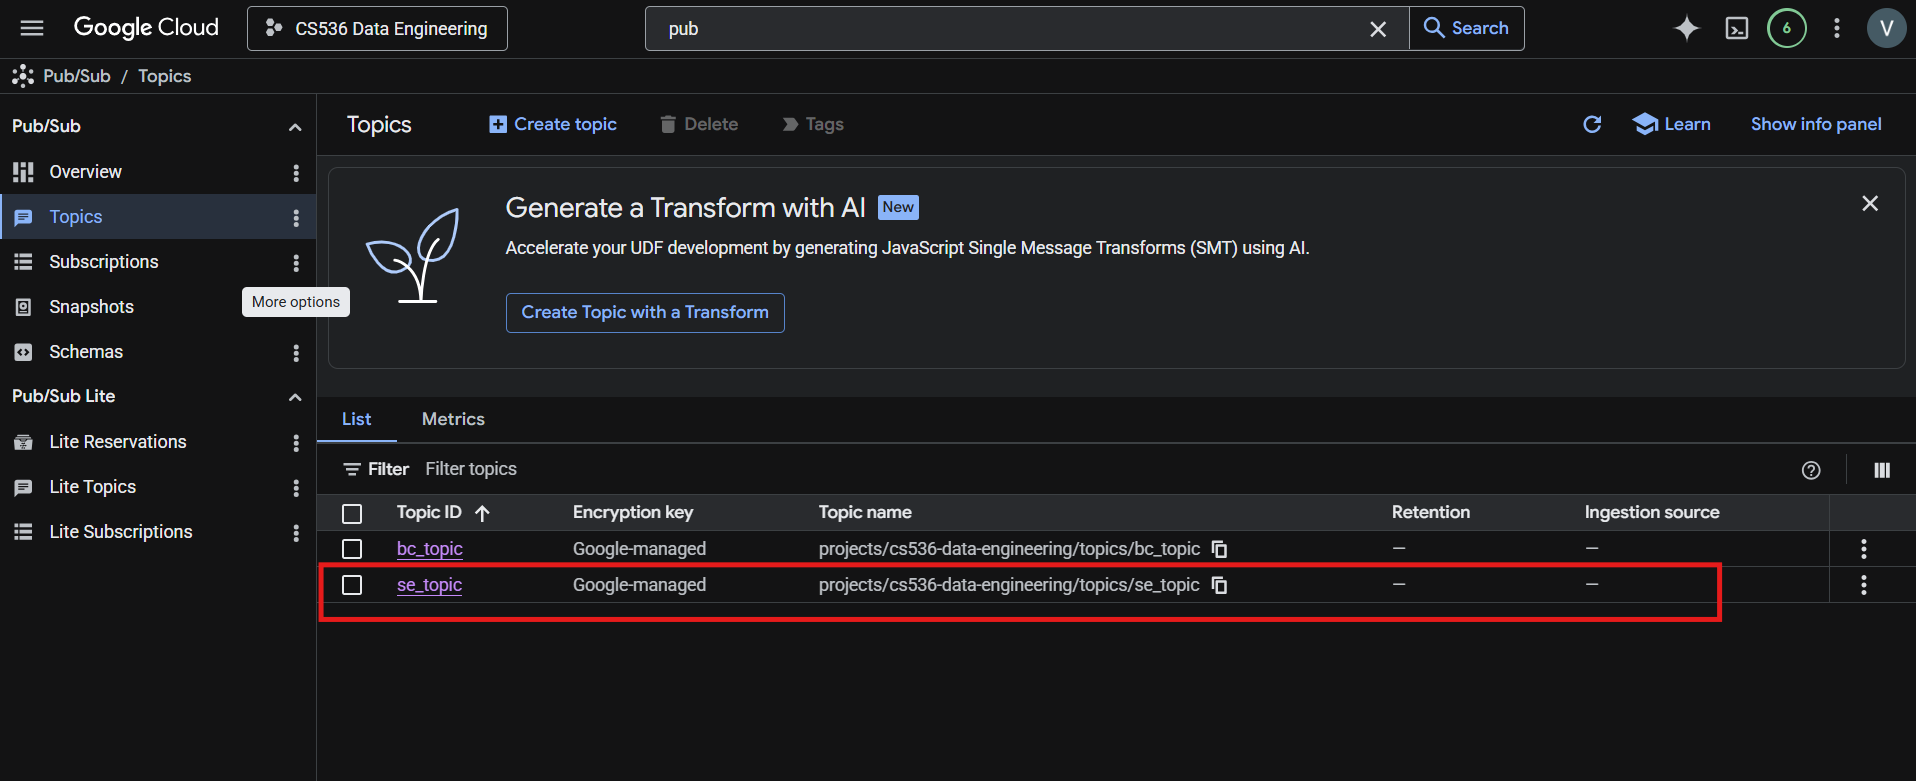

---

### 3.2 Create `se_analysis_sub`

Create a pull subscription named `se_analysis_sub` on `se_topic`. This subscription will
allow your Analysis VM to pull StopEvent messages from `se_topic`.

Paste a screenshot showing `se_analysis_sub` in the subscription list below.

**Screenshot — se_analysis_sub created:**

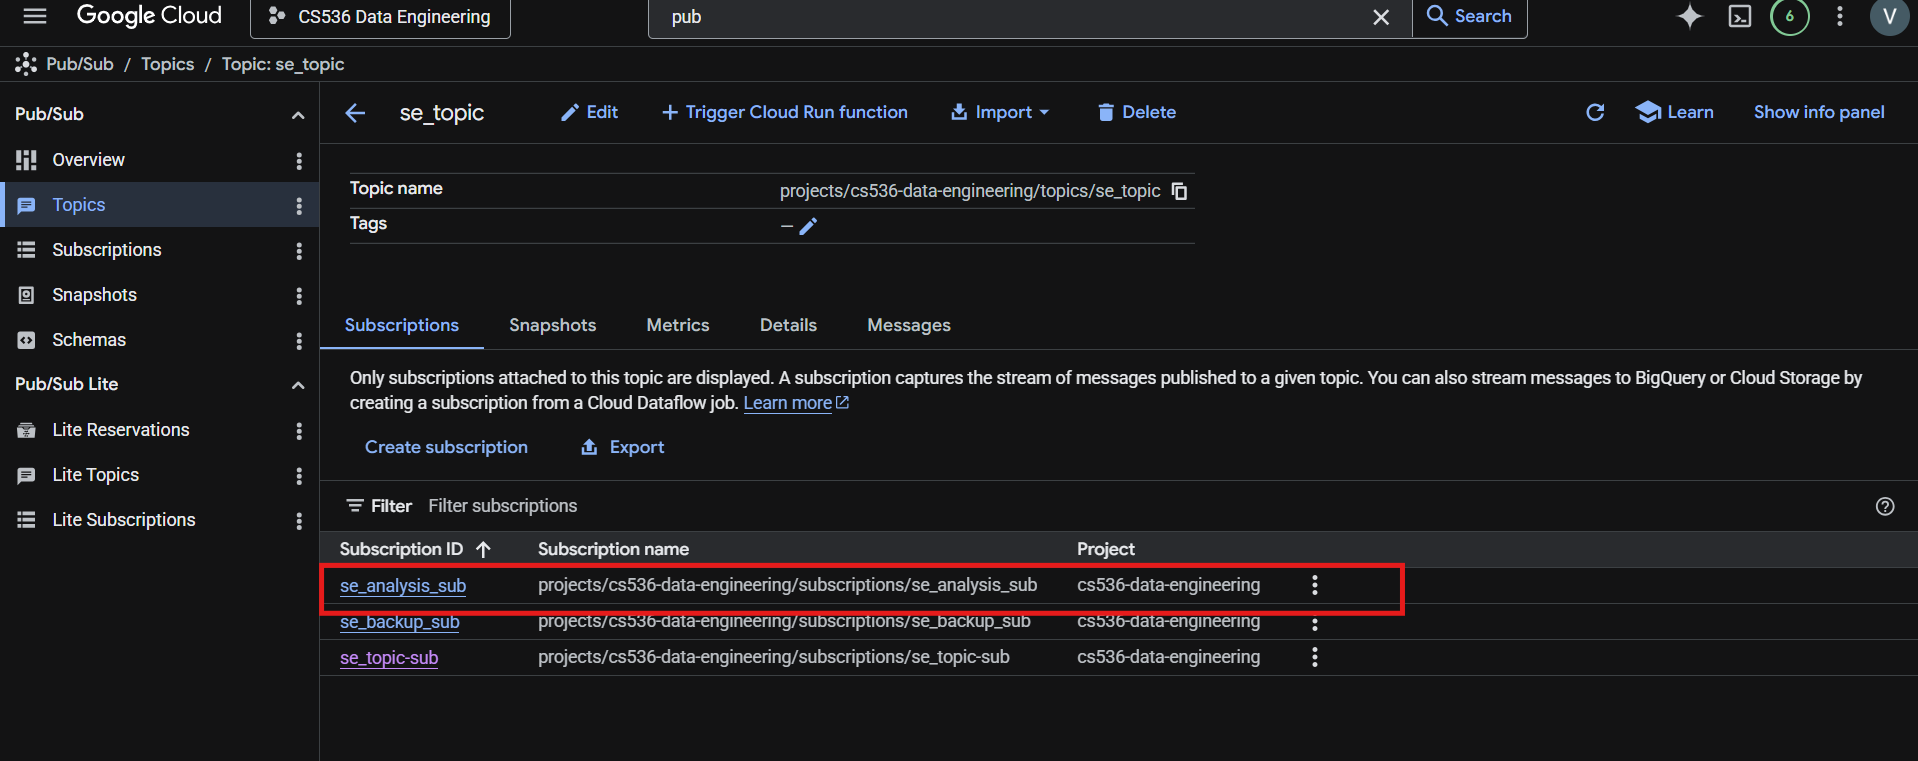

---

### 3.3 Create `se_backup_sub`

Create a pull subscription named `se_backup_sub` on `se_topic`. This subscription will
allow your Backup VM to pull StopEvent messages from `se_topic`.

Paste a screenshot showing `se_backup_sub` in the subscription list below.

**Screenshot — se_backup_sub created:**

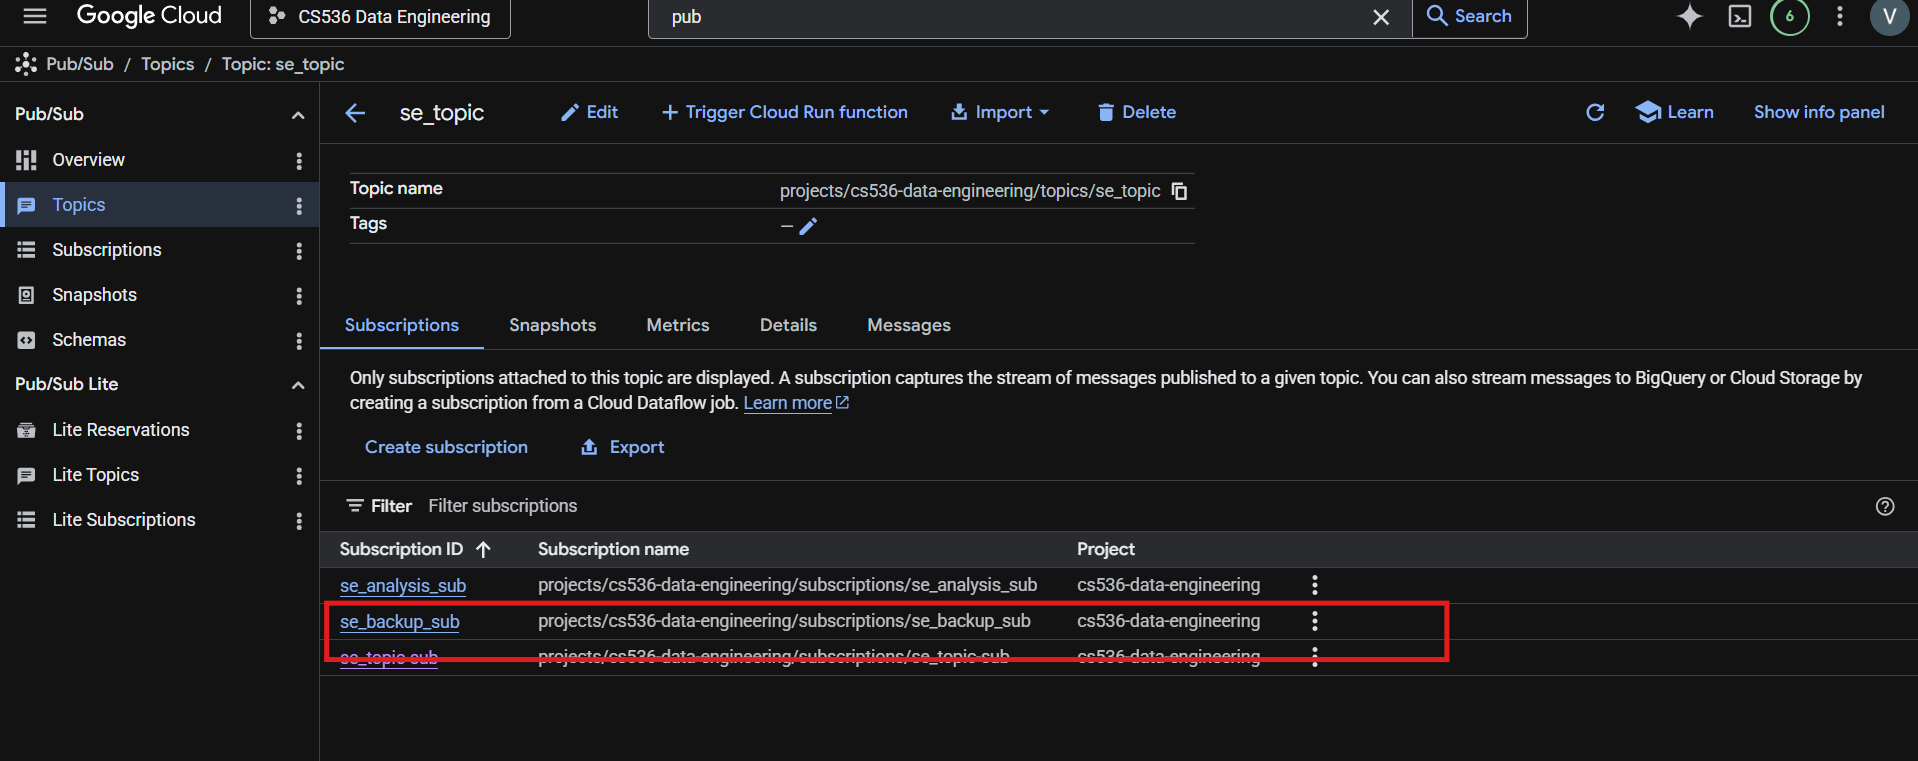

---


## 4. Modify Your Publisher VM

### 4.1 `se_publisher.py`

Add a new program `se_publisher.py` to your Publisher VM. This program does the following:

1. Queries the BusData API for StopEvent data for each of the 222 vehicles in your vehicle group:
   `https://busdata.cs.pdx.edu/api/getStopEvents?vehicle_num=<vehicle_num>`
2. Uses **BeautifulSoup** to parse the HTML response and extract individual StopEvent records.
   (You must implement the BeautifulSoup parsing logic yourself — no scaffolding is provided
   for this step.)
3. Publishes each StopEvent record as a separate JSON message to `se_topic`.
4. After all records are published, sends a sentinel message containing `{"sentinel": true,
   "total_count": <N>}` where `N` is the total number of StopEvent records published.
5. Computes and logs publishing statistics comparable to those logged by your
   BreadCrumb `publisher.py` (records published, elapsed time, throughput, etc.).

Paste your complete, finished `se_publisher.py` in the cell below.

```
import requests
import json
import time
from datetime import datetime
from bs4 import BeautifulSoup
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
TOPIC_ID = "se_topic"

VEHICLE_IDS = [
    2903, 2905, 2907, 2910, 2914, 2915, 2919, 2920, 2921, 2923,
    2924, 2931, 2933, 2939, 3001, 3007, 3010, 3012, 3014, 3018,
    3020, 3027, 3028, 3037, 3042, 3046, 3054, 3055, 3056, 3059,
    3102, 3107, 3108, 3110, 3112, 3113, 3115, 3118, 3121, 3123,
    3125, 3131, 3137, 3138, 3139, 3142, 3144, 3145, 3146, 3158,
    3162, 3166, 3168, 3170, 3204, 3207, 3208, 3209, 3210, 3214,
    3217, 3219, 3223, 3228, 3230, 3231, 3233, 3239, 3240, 3242,
    3246, 3248, 3249, 3250, 3251, 3252, 3260, 3261, 3265, 3267,
    3301, 3304, 3308, 3312, 3315, 3317, 3322, 3326, 3329, 3330,
    3407, 3408, 3412, 3414, 3418, 3505, 3507, 3513, 3518, 3519,
    3521, 3524, 3528, 3529, 3535, 3536, 3545, 3548, 3551, 3552,
    3554, 3561, 3563, 3566, 3568, 3569, 3572, 3576, 3605, 3606,
    3607, 3610, 3611, 3614, 3620, 3621, 3623, 3628, 3631, 3637,
    3647, 3648, 3649, 3702, 3708, 3715, 3716, 3717, 3718, 3719,
    3721, 3724, 3725, 3728, 3730, 3733, 3737, 3739, 3742, 3743,
    3745, 3751, 3755, 3756, 3902, 3909, 3912, 3913, 3915, 3919,
    3925, 3928, 3932, 3935, 3936, 3939, 3940, 3942, 3943, 3950,
    3959, 3962, 3963, 4003, 4006, 4009, 4010, 4021, 4023, 4025,
    4033, 4036, 4042, 4045, 4046, 4050, 4053, 4055, 4059, 4060,
    4066, 4067, 4069, 4070, 4203, 4211, 4213, 4217, 4218, 4219,
    4221, 4222, 4224, 4234, 4239, 4302, 4303, 4304, 4305, 4502,
    4504, 4505, 4511, 4513, 4516, 4517, 4518, 4520, 4522, 4528,
    4530, 4531,
]

FIELDS = [
    "vehicle_number", "leave_time", "train", "route_number",
    "direction", "service_key", "trip_number", "stop_time",
    "arrive_time", "dwell", "location_id", "door", "lift",
    "ons", "offs", "estimated_load", "maximum_speed",
    "train_mileage", "pattern_distance", "location_distance",
    "x_coordinate", "y_coordinate", "data_source", "schedule_status"
]

def parse_stop_events(html, vehicle_id):
    records = []
    soup = BeautifulSoup(html, "html.parser")
    # Extract service date from h1 tag
    h1 = soup.find("h1")
    service_date = None
    if h1:
        import re
        match = re.search(r"(\d{4}-\d{2}-\d{2})", h1.text)
        if match:
            service_date = match.group(1)
    import re
    tables = soup.find_all("table")
    h2_tags = soup.find_all("h2")
    for i, table in enumerate(tables):
        # Extract PDX_TRIP ID from corresponding h2 tag
        pdx_trip_id = None
        if i < len(h2_tags):
            match = re.search(r"PDX_TRIP\s+(\d+)", h2_tags[i].text)
            if match:
                pdx_trip_id = int(match.group(1))
        rows = table.find_all("tr")
        for row in rows[1:]:
            cols = row.find_all("td")
            if len(cols) != len(FIELDS):
                continue
            record = {}
            for j, field in enumerate(FIELDS):
                val = cols[j].text.strip()
                try:
                    if field in ["train_mileage", "pattern_distance",
                                 "location_distance", "x_coordinate",
                                 "y_coordinate"]:
                        record[field] = float(val)
                    elif field == "service_key":
                        record[field] = val
                    else:
                        record[field] = int(val)
                except (ValueError, TypeError):
                    record[field] = None
            record["service_date"] = service_date
            record["pdx_trip_id"] = pdx_trip_id
            records.append(record)
    return records

def main():
    publisher = pubsub_v1.PublisherClient()
    topic_path = publisher.topic_path(PROJECT_ID, TOPIC_ID)
    begin_ts = datetime.now()
    print(f"BEGIN_TIMESTAMP: {begin_ts.isoformat()}")
    total_records = 0
    vehicles_with_data = set()
    for vehicle_id in VEHICLE_IDS:
        url = f"https://busdata.cs.pdx.edu/api/getStopEvents?vehicle_num={vehicle_id}"
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 404:
                continue
            resp.raise_for_status()
        except Exception as e:
            print(f"WARNING: Could not fetch vehicle {vehicle_id}: {e}")
            continue
        records = parse_stop_events(resp.text, vehicle_id)
        if not records:
            continue
        vehicles_with_data.add(vehicle_id)
        futures = []
        for record in records:
            msg = json.dumps(record).encode("utf-8")
            future = publisher.publish(topic_path, msg)
            futures.append(future)
            total_records += 1
        for f in futures:
            f.result()
    time.sleep(5)
    sentinel = json.dumps({"sentinel": True, "total_count": total_records}).encode("utf-8")
    publisher.publish(topic_path, sentinel, sentinel="true").result()
    end_ts = datetime.now()
    elapsed = (end_ts - begin_ts).total_seconds()
    throughput = total_records / elapsed if elapsed > 0 else 0
    print(f"NUM_VEHICLES:    {len(vehicles_with_data)}")
    print(f"NUM_RECORDS:     {total_records}")
    print(f"WALLTIME:        {elapsed:.2f}s")
    print(f"THROUGHPUT:      {throughput:.1f} records/sec")
    print(f"END_TIMESTAMP:   {end_ts.isoformat()}")

if __name__ == "__main__":
    main()
```


### 4.2 Updated Crontab

Add a crontab entry on your Publisher VM to run `se_publisher.py` automatically each day.
Schedule it to run shortly after your existing BreadCrumb `publisher.py` so that both
pipelines run daily without overlap.

Paste the output of `crontab -l` from your Publisher VM below to show both crontab entries.

```
# 10 2 * * * /usr/bin/python3 /home/vinodh/publisher.py >> /home/vinodh/publisher.log 2>&1
15 2 * * * /usr/bin/python3 /home/vinodh/se_publisher.py >> /home/vinodh/se_publisher.log 2>&1
```

Paste a screenshot or log excerpt showing `se_publisher.py` completing a successful run.

**Screenshot / log excerpt:**

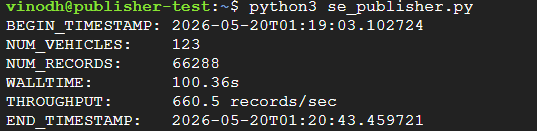

---


## 5. Modify Your Backup VM

### 5.1 `se_backup.py`

Add `se_backup.py` to your Backup VM. It subscribes to `se_backup_sub` on `se_topic`
and archives incoming StopEvent records to a daily compressed file, functioning similarly
to the BreadCrumb `backup.py` program. It should:

- Pull StopEvent messages from `se_backup_sub` in a continuous loop.
- Accumulate records until the sentinel message arrives; once the sentinel is received,
  continue pulling until `total_count` records have been received.
- Write all records to a daily gzip-compressed JSON file
  (e.g., `se_<DATE>.json.gz`).
- Log statistics comparable to those logged by `backup.py`
  (total records received, file size, elapsed time, throughput, etc.).

Paste your complete `se_backup.py` in the cell below.

```
import json
import warnings
warnings.filterwarnings("ignore")
import gzip
import os
import time
from datetime import datetime
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "se_backup_sub"
BACKUP_DIR = "/home/vinodh"

def process_day(subscriber, sub_path):
    today = datetime.now().strftime("%Y-%m-%d")
    filepath = os.path.join(BACKUP_DIR, f"se_{today}.json.gz")
    vehicle_ids = set()
    total = 0
    begin_wall = None
    sentinel_found = False
    total_count = None
    with gzip.open(filepath, "wt") as f:
        while True:
            try:
                response = subscriber.pull(request={"subscription": sub_path, "max_messages": 500}, timeout=10)
            except Exception as e:
                if "504" in str(e) or "Deadline" in str(e):
                    time.sleep(2)
                    continue
                else:
                    raise
            if not response.received_messages:
                if sentinel_found and total_count is not None and total >= total_count:
                    break
                time.sleep(2)
                continue
            ack_ids = []
            for msg in response.received_messages:
                ack_ids.append(msg.ack_id)
                data = json.loads(msg.message.data.decode("utf-8"))
                if data.get("sentinel") or msg.message.attributes.get("sentinel") == "true":
                    sentinel_found = True
                    total_count = data.get("total_count")
                    continue
                if begin_wall is None:
                    begin_wall = datetime.now()
                vid = data.get("vehicle_number")
                if vid is not None:
                    vehicle_ids.add(vid)
                f.write(json.dumps(data) + chr(10))
                total += 1
            if ack_ids:
                subscriber.acknowledge(request={"subscription": sub_path, "ack_ids": ack_ids})
            if sentinel_found and total_count is not None and total >= total_count:
                break
    end_wall = datetime.now()
    raw_size = os.path.getsize(filepath)
    elapsed = (end_wall - begin_wall).total_seconds() if begin_wall else 0
    throughput = total / elapsed if elapsed > 0 else 0
    print(f"BEGIN_TIMESTAMP: {begin_wall.isoformat() if begin_wall else chr(78)+chr(47)+chr(65)}")
    print(f"NUM_RECORDS:     {total}")
    print(f"FILESIZE:        {raw_size} bytes")
    print(f"NUM_VEHICLES:    {len(vehicle_ids)}")
    print(f"END_TIMESTAMP:   {end_wall.isoformat()}")
    print(f"WALLTIME:        {elapsed:.2f}s")
    print(f"THROUGHPUT:      {throughput:.1f} records/sec")

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)
    print("se_backup.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next days data...")
        except Exception as e:
            if "504" in str(e) or "Deadline" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} - retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()
```

---

### 5.2 System Service Configuration

Configure `se_backup.py` to run as a systemd service on your Backup VM, just as you
configured `backup.py` in Part 2. The service should start automatically when the VM boots
and restart if the program exits unexpectedly.

Paste your service unit file (`se_backup.service`) below.

```
# /etc/systemd/system/se_backup.service
# [Unit]
Description=BreadCrumb StopEvent Backup Service
After=network.target

[Service]
Type=simple
User=vinodh
WorkingDirectory=/home/vinodh
ExecStart=/usr/bin/python3 -u /home/vinodh/se_backup.py
Restart=always
RestartSec=10
StandardOutput=append:/home/vinodh/se_backup.log
StandardError=append:/home/vinodh/se_backup.log

[Install]
WantedBy=multi-user.target
```

Paste a screenshot showing `se_backup.service` in a running state
(`sudo systemctl status se_backup`).

**Screenshot — se_backup service running:**

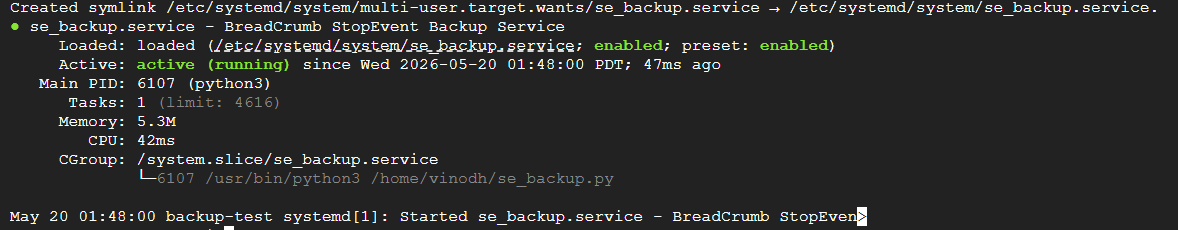

---


## 6. Modify Your Analysis VM

### 6.1 StopEvent Table Schema

Create a `StopEvent` table in your PostgreSQL database. The DDL below defines the schema;
run it on your Analysis VM using `psql`. The x_coordinate and y_coordinate columns from the
raw data are replaced by `GPS_latitude` and `GPS_longitude` after the coordinate transformation
described in Section 6.2.


In [5]:
# Connect to your PostgreSQL database and create the StopEvent table.
# Run this cell from Colab after establishing your database connection (see Section 9.1).
#
# This DDL is provided as scaffolding. You may add or remove columns as needed
# to match the data you are storing, but all columns must be populated.

CREATE_STOPEVENT_TABLE = """
CREATE TABLE IF NOT EXISTS StopEvent (
    vehicle_number   INTEGER      NOT NULL,
    leave_time       TIMESTAMP,
    train            INTEGER,
    route_number     INTEGER,
    direction        SMALLINT,
    service_key      CHAR(1),
    trip_number      INTEGER      NOT NULL,
    stop_time        TIMESTAMP,
    arrive_time      TIMESTAMP    NOT NULL,
    dwell            INTEGER,
    location_id      INTEGER,
    door             INTEGER,
    lift             INTEGER,
    ons              INTEGER,
    offs             INTEGER,
    estimated_load   INTEGER,
    maximum_speed    INTEGER,
    train_mileage    FLOAT,
    pattern_distance FLOAT,
    location_distance FLOAT,
    GPS_latitude     FLOAT,
    GPS_longitude    FLOAT,
    data_source      SMALLINT,
    schedule_status  SMALLINT,
    PRIMARY KEY (vehicle_number, trip_number, arrive_time)
);
"""


print("StopEvent DDL ready.")
print("Run this DDL using your psql connection in Section 9.1.")
print()
print(CREATE_STOPEVENT_TABLE)


StopEvent DDL ready.
Run this DDL using your psql connection in Section 9.1.


CREATE TABLE IF NOT EXISTS StopEvent (
    vehicle_number   INTEGER      NOT NULL,
    leave_time       TIMESTAMP,
    train            INTEGER,
    route_number     INTEGER,
    direction        SMALLINT,
    service_key      CHAR(1),
    trip_number      INTEGER      NOT NULL,
    stop_time        TIMESTAMP,
    arrive_time      TIMESTAMP    NOT NULL,
    dwell            INTEGER,
    location_id      INTEGER,
    door             INTEGER,
    lift             INTEGER,
    ons              INTEGER,
    offs             INTEGER,
    estimated_load   INTEGER,
    maximum_speed    INTEGER,
    train_mileage    FLOAT,
    pattern_distance FLOAT,
    location_distance FLOAT,
    GPS_latitude     FLOAT,
    GPS_longitude    FLOAT,
    data_source      SMALLINT,
    schedule_status  SMALLINT,
    PRIMARY KEY (vehicle_number, trip_number, arrive_time)
);



Paste a screenshot showing the `\d StopEvent` output from `psql` confirming
that the table was created successfully.

**Screenshot — StopEvent table schema:**

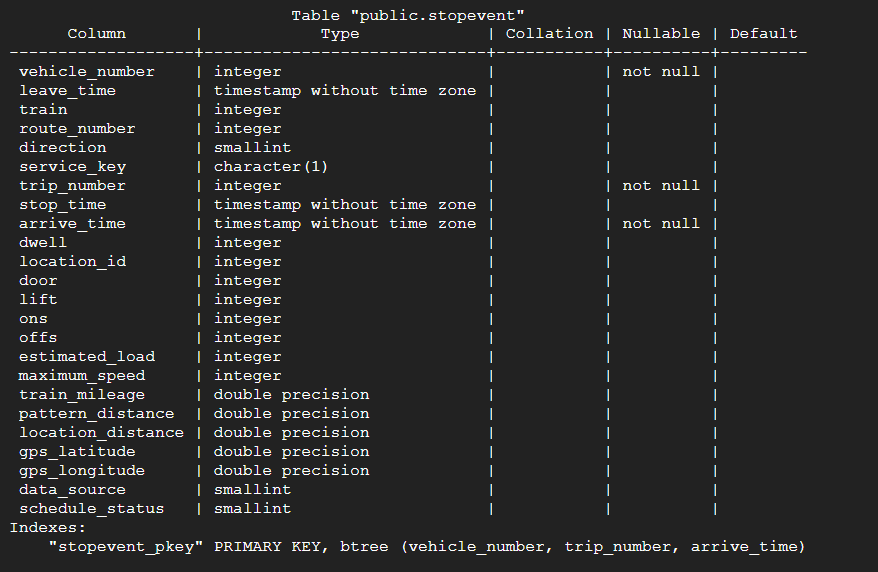

---

### 6.2 `se_analysis.py`

Add `se_analysis.py` to your Analysis VM. It subscribes to `se_analysis_sub` on
`se_topic`, validates, transforms, and loads StopEvent records into the `StopEvent`
table in your PostgreSQL database.

#### Validations

You must implement **at least 8 validations**. The table below defines 2 of them;
you must define and implement the remaining 6 or more.

| # | Assertion | Type | Action on Violation |
|---|---|---|---|
| 1 | `arrive_time` must be non-null and in the range [0, 108000] | Limit | Drop record |
| 2 | `leave_time` must be non-null, and `leave_time >= arrive_time` | Intra-record | Drop record |
| 3 | `vehicle_number` must not be null | Existence | Drop record |
| 4 | `trip_number` must not be null | Existence | Drop record |
| 5 | `route_number` must not be null and must be > 0 | Limit | Drop record |
| 6 | `ons` must be >= 0 and `offs` must be >= 0 | Limit | Drop record |
| 7 | `estimated_load` must be >= 0 | Limit | Drop record |
| 8 | `location_id` must not be null | Existence | Drop record |
| 9 | `service_key` must be one of W, S, or U | Existence | Drop record |
| 10 | `dwell` must be >= 0 | Limit | Drop record |

#### Transformations

You must implement both of the following transformations:

**Transformation 1 — Convert time fields to timestamps.**
The fields `leave_time`, `stop_time`, and `arrive_time` are stored as integer seconds
past midnight relative to midnight of the service date. Convert each to a proper Python `datetime`
(and subsequently a PostgreSQL `TIMESTAMP`) by adding the seconds value to the midnight of the base service date.

**Transformation 2 — Convert State Plane coordinates to GPS lat/lon.**
The `x_coordinate` and `y_coordinate` fields use the Oregon State Plane Coordinate
System (SPCS83 Oregon North Zone, EPSG:2913, units: international feet). Use the
scaffolding code below to convert these to WGS 84 `GPS_latitude` and `GPS_longitude`.
Store the converted values in place of `x_coordinate` and `y_coordinate`.

The coordinate conversion is handled by the `pyproj` library:


In [6]:
# Coordinate transformation scaffolding
# Include this code in se_analysis.py to convert State Plane coordinates
# to GPS latitude and longitude.

from pyproj import Transformer

# Create a transformer: EPSG:2913 (Oregon State Plane North, feet) -> WGS 84
_transformer = Transformer.from_crs("EPSG:2913", "EPSG:4326", always_xy=True)


def state_plane_to_latlon(x_coordinate, y_coordinate):
    """
    Convert Oregon State Plane Coordinate System coordinates (EPSG:2913)
    to WGS 84 GPS latitude and longitude.

    Parameters
    ----------
    x_coordinate : float
        Easting in international feet (SPCS83 Oregon North Zone).
    y_coordinate : float
        Northing in international feet (SPCS83 Oregon North Zone).

    Returns
    -------
    tuple[float, float]
        (GPS_latitude, GPS_longitude) in decimal degrees (WGS 84).
    """
    lon, lat = _transformer.transform(x_coordinate, y_coordinate)
    return lat, lon


# Example
lat, lon = state_plane_to_latlon(7666298.96, 677239.73)
print(f"State Plane (7666298.96, 677239.73) -> lat={lat:.6f}, lon={lon:.6f}")
# Expected output near: lat=45.494, lon=-122.591


State Plane (7666298.96, 677239.73) -> lat=45.505276, lon=-122.590137


Paste your complete, finished `se_analysis.py` in the cell below.

```
import json, time, logging, psycopg2
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta, date
from google.cloud import pubsub_v1
from pyproj import Transformer

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "se_analysis_sub"
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "breadcrumbs"
DB_USER = "vinodh"
DB_PASS = "password123"

logging.basicConfig(level=logging.CRITICAL, format="%(asctime)s %(levelname)s %(message)s")

_transformer = Transformer.from_crs("EPSG:2913", "EPSG:4326", always_xy=True)

def state_plane_to_latlon(x, y):
    lon, lat = _transformer.transform(x, y)
    return lat, lon

def get_service_date(record=None):
    if record and record.get("service_date"):
        try:
            return datetime.strptime(record["service_date"], "%Y-%m-%d")
        except:
            pass
    return datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)

def seconds_to_timestamp(seconds, base_date):
    if seconds is None:
        return None
    return base_date + timedelta(seconds=int(seconds))

def validate_record(record):
    violations = []
    arrive = record.get("arrive_time")
    if arrive is None or not (0 <= arrive <= 108000):
        violations.append("arrive_time is null or out of range [0, 108000]")
    leave = record.get("leave_time")
    if leave is None:
        violations.append("leave_time is null")
    elif arrive is not None and leave < arrive:
        violations.append("leave_time is less than arrive_time")
    if record.get("vehicle_number") is None:
        violations.append("vehicle_number is null")
    if record.get("trip_number") is None:
        violations.append("trip_number is null")
    route = record.get("route_number")
    if route is None or route <= 0:
        violations.append("route_number is null or <= 0")
    ons = record.get("ons")
    offs = record.get("offs")
    if ons is None or ons < 0:
        violations.append("ons is null or negative")
    if offs is None or offs < 0:
        violations.append("offs is null or negative")
    load = record.get("estimated_load")
    if load is None or load < 0:
        violations.append("estimated_load is null or negative")
    if record.get("location_id") is None:
        violations.append("location_id is null")
    sk = record.get("service_key")
    if sk not in ["W", "S", "U"]:
        violations.append("service_key is not W, S, or U")
    dwell = record.get("dwell")
    if dwell is None or dwell < 0:
        violations.append("dwell is null or negative")
    if violations:
        return False, violations
    return True, []

def transform_record(record):
    base_date = get_service_date(record)
    record.pop("service_date", None)
    record["arrive_time"] = seconds_to_timestamp(record.get("arrive_time"), base_date)
    record["leave_time"]  = seconds_to_timestamp(record.get("leave_time"), base_date)
    record["stop_time"]   = seconds_to_timestamp(record.get("stop_time"), base_date)
    x = record.pop("x_coordinate", None)
    y = record.pop("y_coordinate", None)
    if x is not None and y is not None:
        lat, lon = state_plane_to_latlon(x, y)
        record["GPS_latitude"]  = lat
        record["GPS_longitude"] = lon
    else:
        record["GPS_latitude"]  = None
        record["GPS_longitude"] = None
    return record

def insert_record(cur, r):
    # Use pdx_trip_id if available, otherwise fall back to trip_number
    trip_num = r.get("pdx_trip_id") or r.get("trip_number")
    cur.execute("""
        INSERT INTO stopevent (
            vehicle_number, leave_time, train, route_number, direction,
            service_key, trip_number, stop_time, arrive_time, dwell,
            location_id, door, lift, ons, offs, estimated_load,
            maximum_speed, train_mileage, pattern_distance,
            location_distance, GPS_latitude, GPS_longitude,
            data_source, schedule_status
        ) VALUES (
            %s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s
        ) ON CONFLICT DO NOTHING
    """, (
        r.get("vehicle_number"), r.get("leave_time"), r.get("train"),
        r.get("route_number"), r.get("direction"), r.get("service_key"),
        trip_num, r.get("stop_time"), r.get("arrive_time"),
        r.get("dwell"), r.get("location_id"), r.get("door"), r.get("lift"),
        r.get("ons"), r.get("offs"), r.get("estimated_load"),
        r.get("maximum_speed"), r.get("train_mileage"), r.get("pattern_distance"),
        r.get("location_distance"), r.get("GPS_latitude"), r.get("GPS_longitude"),
        r.get("data_source"), r.get("schedule_status")
    ))

def process_day(subscriber, sub_path):
    conn = psycopg2.connect(host=DB_HOST, port=DB_PORT, dbname=DB_NAME, user=DB_USER, password=DB_PASS)
    conn.autocommit = True
    cur = conn.cursor()
    vehicle_ids, trip_ids = set(), set()
    total, stored, errors = 0, 0, 0
    invalid_records = []
    begin_wall = None
    sentinel_found, total_count = False, None
    while True:
        try:
            response = subscriber.pull(request={"subscription": sub_path, "max_messages": 500}, timeout=10)
        except Exception as e:
            if "504" in str(e) or "Deadline" in str(e):
                time.sleep(2)
                continue
            else:
                raise
        if not response.received_messages:
            if sentinel_found and total_count is not None and total >= total_count:
                break
            time.sleep(2)
            continue
        ack_ids = []
        for msg in response.received_messages:
            ack_ids.append(msg.ack_id)
            data = json.loads(msg.message.data.decode("utf-8"))
            if data.get("sentinel") or msg.message.attributes.get("sentinel") == "true":
                sentinel_found = True
                total_count = data.get("total_count")
                continue
            if begin_wall is None:
                begin_wall = datetime.now()
            total += 1
            is_valid, violations = validate_record(data)
            if not is_valid:
                errors += 1
                invalid_records.append({"violations": violations, "record": data})
                continue
            record = transform_record(data)
            if record.get("vehicle_number"): vehicle_ids.add(record["vehicle_number"])
            if record.get("trip_number"): trip_ids.add(record["trip_number"])
            try:
                insert_record(cur, record)
                stored += 1
            except Exception as e:
                logging.warning("DB error: %s", e)
        if ack_ids:
            subscriber.acknowledge(request={"subscription": sub_path, "ack_ids": ack_ids})
        if sentinel_found and total_count is not None and total >= total_count:
            break
    if invalid_records:
        fname = f"/home/vinodh/se_invalid_{date.today().isoformat()}.json"
        with open(fname, "w") as f:
            json.dump(invalid_records, f, indent=2, default=str)
    end_wall = datetime.now()
    elapsed = (end_wall - begin_wall).total_seconds() if begin_wall else 0
    tp = total / elapsed if elapsed > 0 else 0
    print(f"BEGIN_TIMESTAMP:   {begin_wall.isoformat() if begin_wall else "N/A"}")
    print(f"NUM_VEHICLES:      {len(vehicle_ids)}")
    print(f"NUM_TRIPS:         {len(trip_ids)}")
    print(f"NUM_RECORDS:       {total}")
    print(f"VALIDATION_ERRORS: {errors}")
    print(f"STORED:            {stored}")
    print(f"END_TIMESTAMP:     {end_wall.isoformat()}")
    print(f"WALLTIME:          {elapsed:.2f}s")
    print(f"THROUGHPUT:        {tp:.1f} records/sec")
    cur.close()
    conn.close()

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)
    print("se_analysis.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next day...")
        except Exception as e:
            if "504" in str(e) or "Deadline" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} - retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()
```

---

### 6.3 System Service Configuration

Configure `se_analysis.py` as a systemd service on your Analysis VM, just as you
configured `analysis.py` in Part 2.

Paste your service unit file (`se_analysis.service`) below.

```
# /etc/systemd/system/se_analysis.service
# [Unit]
Description=StopEvent Analysis Service
After=network.target

[Service]
Type=simple
User=vinodh
WorkingDirectory=/home/vinodh
ExecStart=/usr/bin/python3 -u /home/vinodh/se_analysis.py
Restart=always
RestartSec=10
StandardOutput=append:/home/vinodh/se_analysis.log
StandardError=append:/home/vinodh/se_analysis.log

[Install]
WantedBy=multi-user.target
```

Paste a screenshot showing `se_analysis.service` in a running state.

**Screenshot — se_analysis service running:**

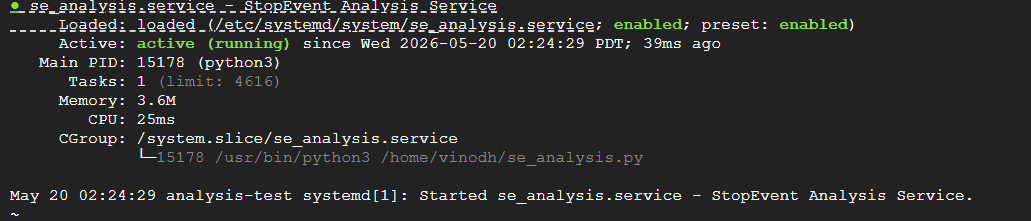

---


## 7. Run Both Pipelines Daily and Debug Issues

You now have two data pipelines flowing into your PostgreSQL database: the BreadCrumb
pipeline (updating the `BreadCrumb` table) and the StopEvent pipeline (updating the
`StopEvent` table). Running a complex system like this reliably takes care and attention.

### 7.1 Monitor GCP Credits

GCP projects are funded by credits. Although you should have sufficient credits for this
project, it is possible for them to run low.

**How to check remaining GCP credits:**

1. In the GCP console, click the navigation menu (three horizontal lines, top left).
2. Navigate to **Billing**.
3. Select your billing account. Your remaining credits and recent usage are displayed
   on the **Overview** page under **Credits**.
4. Alternatively, navigate to **Reports** within Billing to see a breakdown of spending
   by service and time period.

If your remaining credits fall below $10, contact us immediately. To
conserve credits, shut down VMs when they are not needed and restart them before your
scheduled pipeline runs.

---

### 7.2 Monitor Storage Space

Each VM has a limited amount of disk space. Monitor filesystem capacity on each VM and
expand storage if necessary.

**How to check filesystem space capacity and utilization:**

Run the following commands on each VM via SSH:

```bash
# Show filesystem disk usage for all mounted filesystems
df -h

# Show disk usage of specific directories (e.g., your home directory and backup files)
du -sh ~
du -sh /path/to/your/backup/directory
```

The `df -h` output shows total size, used space, available space, and percentage used
for each filesystem. Pay attention to the filesystem that holds your home directory
(typically `/`) and any data directories where backup files or postgres files accumulate.

**How to expand a VM's storage capacity:**

If a VM is running low on disk space, you can expand it using the GCP console:

1. In the GCP console, navigate to **Compute Engine > Disks**.
2. Click on the name of the disk attached to the VM that needs more space.
3. Click **Edit** at the top of the disk detail page.
4. Increase the **Size** field to the desired capacity (you can only increase, not decrease).
5. Click **Save**.
6. SSH into the VM and resize the filesystem to use the newly allocated space:

```bash
# Identify the partition (e.g., /dev/sda1)
lsblk

# Grow the partition to fill the disk (use the correct disk and partition names)
sudo growpart /dev/sda 1

# Resize the filesystem (ext4 example)
sudo resize2fs /dev/sda1
```

After resizing, verify the new capacity with `df -h`.

---

### 7.3 Verify Both Pipelines Are Running Correctly

Periodically run ad hoc queries to confirm that data is flowing into both tables.


In [15]:
# Run this cell (after completing Section 9.1 to establish the database connection)
# to verify that both tables are receiving data.
# Note: Our breadcrumb table uses 'timestamp' instead of 'tstamp'

import pandas as pd

verify_queries = {
    "BreadCrumb row count": "SELECT COUNT(*) AS breadcrumb_count FROM breadcrumb;",
    "StopEvent row count" : "SELECT COUNT(*) AS stopevent_count FROM StopEvent;",
    "Recent BreadCrumbs"  : """SELECT DATE(timestamp) AS date, COUNT(*) AS count
                                 FROM breadcrumb
                                 GROUP BY DATE(timestamp)
                                 ORDER BY date DESC
                                 LIMIT 5;""",
    "Recent StopEvents"   : """SELECT DATE(arrive_time) AS date, COUNT(*) AS count
                                 FROM StopEvent
                                 GROUP BY DATE(arrive_time)
                                 ORDER BY date DESC
                                 LIMIT 5;""",
}

cur = conn.cursor()

for label, sql in verify_queries.items():
    print(f"--- {label} ---")
    cur.execute(sql)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df = pd.DataFrame(rows, columns=cols)
    print(df.to_string(index=False))
    print()

--- BreadCrumb row count ---
 breadcrumb_count
         30127745

--- StopEvent row count ---
 stopevent_count
          343060

--- Recent BreadCrumbs ---
      date   count
2023-01-26      10
2023-01-25 1486174
2023-01-24 2163063
2023-01-23 2589183
2023-01-22 1006731

--- Recent StopEvents ---
      date  count
2023-01-26   2119
2023-01-25  94849
2023-01-24  90805
2023-01-23  91953
2023-01-22  63334



---


## 8. Pipeline Run Statistics

Record three successful days of full end-to-end automated pipeline runs in the table below.
The three days do not need to be contiguous. For each day, gather the required statistics
from your publisher and subscriber logs.

All values in a given row (BREADCRUMBS, STOPEVENTS, VEHICLES) should be consistent across
all three programs for that pipeline date.

**How to retrieve log statistics:**

- On the Publisher VM: `sudo journalctl -u your_publisher_service --since "<date>"`
  or check your cron log: `grep "se_publisher" /var/log/syslog`
- On the Analysis VM: `sudo journalctl -u se_analysis --since "<date>"`
- On the Backup VM: `sudo journalctl -u se_backup --since "<date>"`

| PIPELINE DATE | TRIMET DATE | BREADCRUMBS | STOPEVENTS | BC_STORED | SE_STORED | VEHICLES | BC_THROUGHPUT (rec/s) | SE_THROUGHPUT (rec/s) |
|---|---|---|---|---|---|---|---|---|
| 2026-05-21 | 2023-01-22 | 515,711 | 64,622 | 503,172 | 63,334 | 123 | 533.2 | 450.0 |
| 2026-05-23 | 2023-01-24 | 734,797 | 90,965 | 720,790 | 90,965 | 153 | 578.2 | 303.9 |
| 2026-05-24 | 2023-01-25 | 763,692 | 95,632 | 743,877 | 95,632 | 158 | 310.9 | 302.3 |


**Column definitions:**

- **PIPELINE DATE** — The calendar date on which the pipeline ran (when publisher.py and se_publisher.py were executed).
- **TRIMET DATE** — The date represented by the timestamp field of BreadCrumb records processed on that pipeline date.
- **BREADCRUMBS** — Total number of BreadCrumb records published and received.
- **STOPEVENTS** — Total number of StopEvent records published and received.
- **BC_STORED** — Number of BreadCrumb records successfully stored in the `BreadCrumb` table.
- **SE_STORED** — Number of StopEvent records successfully stored in the `StopEvent` table.
- **VEHICLES** — Number of unique vehicle_id values observed on this pipeline date (publishers and subscribers should agree).
- **BC_THROUGHPUT** — BreadCrumb messages processed per second by `analysis.py`.
- **SE_THROUGHPUT** — StopEvent messages processed per second by `se_analysis.py`.

---


## 9. Data Analysis

### 9.1 Connect to the Database

Use the cell below to establish a connection from Colab to your PostgreSQL database on
the Analysis VM. Configure the connection parameters to match your setup from Part 2.


In [8]:
# Install psycopg2 if it is not already available
!pip install psycopg2-binary --quiet

import psycopg2
import pandas as pd

# Update the connection parameters to match your PostgreSQL configuration
DB_HOST     = "35.189.246.18"
DB_NAME     = "breadcrumbs"
DB_USER     = "vinodh"
DB_PASSWORD = "password123"
DB_PORT     = 5432

conn = psycopg2.connect(
    host=DB_HOST,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    port=DB_PORT
)

print("Database connection established.")
print(f"Connected to: {DB_NAME} on {DB_HOST}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 14.7 MB/s eta 0:00:00
Database connection established.
Connected to: breadcrumbs on 35.189.246.18


In [10]:
CREATE_STOPEVENT_TABLE = """
CREATE TABLE IF NOT EXISTS StopEvent (
    vehicle_number   INTEGER      NOT NULL,
    leave_time       TIMESTAMP,
    train            INTEGER,
    route_number     INTEGER,
    direction        SMALLINT,
    service_key      CHAR(1),
    trip_number      INTEGER      NOT NULL,
    stop_time        TIMESTAMP,
    arrive_time      TIMESTAMP    NOT NULL,
    dwell            INTEGER,
    location_id      INTEGER,
    door             INTEGER,
    lift             INTEGER,
    ons              INTEGER,
    offs             INTEGER,
    estimated_load   INTEGER,
    maximum_speed    INTEGER,
    train_mileage    FLOAT,
    pattern_distance FLOAT,
    location_distance FLOAT,
    GPS_latitude     FLOAT,
    GPS_longitude    FLOAT,
    data_source      SMALLINT,
    schedule_status  SMALLINT,
    PRIMARY KEY (vehicle_number, trip_number, arrive_time)
);
"""

cur = conn.cursor()
cur.execute(CREATE_STOPEVENT_TABLE)
conn.commit()
print("StopEvent table ready!")

StopEvent table ready!


---

### 9.2 Example Analysis Query

The cell below demonstrates how to use Python and SQL to answer an analysis question.
It lists each day of the week and shows the number of trips recorded for that day across
both tables, ordered from busiest to quietest weekday.


In [11]:
# Example: Number of trips per day of the week (from BreadCrumb data)

sql_example = """
    SELECT
        TO_CHAR(timestamp, 'Day')   AS day_of_week,
        EXTRACT(DOW FROM timestamp) AS dow_number,
        COUNT(DISTINCT trip_id) AS num_trips
    FROM breadcrumb
    GROUP BY day_of_week, dow_number
    ORDER BY dow_number;
"""

cur.execute(sql_example)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_example = pd.DataFrame(rows, columns=cols)
print("Number of trips per day of the week:")
print(df_example.to_string(index=False))

Number of trips per day of the week:
day_of_week dow_number  num_trips
  Sunday             0       3703
  Monday             1       4785
  Tuesday            2       5692
  Wednesday          3       5504
  Thursday           4       5599
  Friday             5       5355
  Saturday           6       3802


---

### 9.3 Your Analysis Queries

Answer each of the following questions by writing a Python cell that executes a SQL
query and displays the results. At least one of these three queries must join the
`BreadCrumb` and `StopEvent` tables.

---

**Query 1:** For each date in your dataset, show the total number of BreadCrumb records
stored and the total number of StopEvent records stored. Order by date.


In [16]:
# Query 1: Daily BreadCrumb and StopEvent counts
sql_q1 = """
    SELECT
        bc.date,
        bc.breadcrumb_count,
        COALESCE(se.stopevent_count, 0) AS stopevent_count
    FROM (
        SELECT DATE(timestamp) AS date, COUNT(*) AS breadcrumb_count
        FROM breadcrumb
        GROUP BY DATE(timestamp)
    ) bc
    LEFT JOIN (
        SELECT DATE(arrive_time) AS date, COUNT(*) AS stopevent_count
        FROM stopevent
        GROUP BY DATE(arrive_time)
    ) se ON bc.date = se.date
    ORDER BY bc.date;
"""

cur.execute(sql_q1)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_q1 = pd.DataFrame(rows, columns=cols)
print("Query 1 results:")
print(df_q1.to_string(index=False))

Query 1 results:
      date  breadcrumb_count  stopevent_count
2023-01-05           1519823                0
2023-01-06            700865                0
2023-01-07           2051146                0
2023-01-08            519106                0
2023-01-09           1375912                0
2023-01-10           1496758                0
2023-01-11           1432000                0
2023-01-12           1453636                0
2023-01-13           1403924                0
2023-01-14           1052966                0
2023-01-15            694061                0
2023-01-16            999796                0
2023-01-17           1496184                0
2023-01-18           1414324                0
2023-01-19           1335070                0
2023-01-20           1343448                0
2023-01-21           2593565                0
2023-01-22           1006731            63334
2023-01-23           2589183            91953
2023-01-24           2163063            90805
2023-01-25       

**Query 2:** Show the top 10 routes (by route_number) ordered by total
passenger boardings (`ons`), along with the total number of stop events and total boardings
for each route.


In [ ]:
# Query 2: Top 10 routes by total boardings
sql_q2 = """
    SELECT
        route_number,
        COUNT(*) AS total_stop_events,
        SUM(ons) AS total_boardings
    FROM stopevent
    GROUP BY route_number
    ORDER BY total_boardings DESC
    LIMIT 10;
"""

cur.execute(sql_q2)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_q2 = pd.DataFrame(rows, columns=cols)
print("Query 2 results:")
print(df_q2.to_string(index=False))

Query 2 results:
 route_number  total_stop_events  total_boardings
           72              17182             8472
           20              19684             7211
            2               9347             6135
            9              11127             4858
            6               9388             4768
           75              12322             4279
           15              11494             4274
           57               8358             4013
           14               5984             3758
           33               9386             3608


**Query 3 (join required):** For each route, show the average BreadCrumb
`SPEED` during trips that had at least 10 total passenger boardings (`ons`)
during the trip. This query requires joining the `BreadCrumb` table and the `StopEvent` table
on `trip_number`. Show the route number, average velocity, and number of qualifying trips.
Order by average velocity descending.


In [ ]:
# Query 3: Average velocity per route for trips with >= 10 total boardings
sql_q3 = """
    SELECT
        se.route_number,
        ROUND(AVG(bc.speed)::numeric, 4) AS avg_speed_mps,
        COUNT(DISTINCT se.trip_number) AS qualifying_trips
    FROM breadcrumb bc
    JOIN (
        SELECT trip_number, route_number, SUM(ons) AS total_ons
        FROM stopevent
        GROUP BY trip_number, route_number
        HAVING SUM(ons) >= 10
    ) se ON bc.trip_id = se.trip_number
    GROUP BY se.route_number
    ORDER BY avg_speed_mps DESC;
"""

cur.execute(sql_q3)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_q3 = pd.DataFrame(rows, columns=cols)
print("Query 3 results:")
print(df_q3.to_string(index=False))

Query 3 results:
 route_number avg_speed_mps  qualifying_trips
           30       14.1579                19
           11       12.2479                 4
           16       11.6376                 9
           96       11.5209                 2
           81       10.5832                12
           57       10.2638               119
           21       10.0282                63
           48       10.0183                32
           62        9.8359                30
           94        9.8235                53
           87        9.8169                27
           88        9.7722                43
           47        9.7721                27
           58        9.7391                13
           67        9.6252                14
           74        9.5525                19
           35        9.2561                16
           85        9.0548                 8
           52        9.0153                47
           32        8.8972                17
           56    

---

### 9.4 Additional Queries of Your Choice

Write **3 additional queries** of your own design. At least one must require a join between
the `BreadCrumb` and `StopEvent` tables. For each query, briefly describe what question it
answers, write the SQL, and show the results.


**Additional Query 1:**

[Describe what question this query answers]

Which vehicles have the highest average passenger load?


In [ ]:
# Additional Query 1
# Question: Which vehicles carry the most passengers on average per stop?
# This helps identify the busiest buses in the fleet.

sql_aq1 = """
    SELECT
        vehicle_number,
        ROUND(AVG(estimated_load)::numeric, 2) AS avg_passenger_load,
        COUNT(*) AS total_stops,
        SUM(ons) AS total_boardings,
        SUM(offs) AS total_alightings
    FROM stopevent
    GROUP BY vehicle_number
    ORDER BY avg_passenger_load DESC
    LIMIT 10;
"""

cur.execute(sql_aq1)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_aq1 = pd.DataFrame(rows, columns=cols)
print("Additional Query 1 results:")
print(df_aq1.to_string(index=False))

Additional Query 1 results:
 vehicle_number avg_passenger_load  total_stops  total_boardings  total_alightings
           3637              12.90          414              302               308
           3110              11.94          610              366               380
           3139              11.10          640              438               390
           3304              11.03         1841             1147              1177
           3125               9.90         1066              633               639
           4234               9.70          856              396               397
           3935               9.66         1625              734               733
           3942               9.57         1845              901               926
           4006               9.54          912              476               476
           3730               9.51          361              320               351


**Additional Query 2:**

[Describe what question this query answers]

What is the on-time performance percentage per route?


In [ ]:
# Additional Query 2
# Question: What is the on-time performance percentage per route?
# schedule_status: 5 = on time, 2 = late
# Shows routes ordered by on-time percentage descending

sql_aq2 = """
    SELECT
        route_number,
        COUNT(*) AS total_stops,
        SUM(CASE WHEN schedule_status = 5 THEN 1 ELSE 0 END) AS on_time_stops,
        ROUND(
            100.0 * SUM(CASE WHEN schedule_status = 5 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS on_time_percentage
    FROM stopevent
    GROUP BY route_number
    HAVING COUNT(*) > 100
    ORDER BY on_time_percentage DESC
    LIMIT 10;
"""

cur.execute(sql_aq2)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_aq2 = pd.DataFrame(rows, columns=cols)
print("Additional Query 2 results:")
print(df_aq2.to_string(index=False))

Additional Query 2 results:
 route_number  total_stops  on_time_stops on_time_percentage
           63          193             16               8.29
           66          141              8               5.67
          155          476             23               4.83
           79          378             18               4.76
           99          197              8               4.06
           25          377             15               3.98
           58         1130             45               3.98
           74         1316             50               3.80
           67          441             16               3.63
           59          114              4               3.51


**Additional Query 3:**

[Describe what question this query answers]

For each route, what is the average dwell time at stops


In [ ]:
# Additional Query 3
# Question: For each route, compare average dwell time at stops
# with average bus speed between stops.

sql_aq3 = """
    SELECT
        se.route_number,
        ROUND(AVG(se.dwell)::numeric, 2) AS avg_dwell_seconds,
        ROUND(AVG(bc.speed)::numeric, 4) AS avg_speed_mps,
        COUNT(DISTINCT se.trip_number) AS num_trips
    FROM stopevent se
    JOIN breadcrumb bc ON se.trip_number = bc.trip_id
    WHERE se.dwell > 0
    GROUP BY se.route_number
    HAVING COUNT(DISTINCT se.trip_number) > 3
    ORDER BY avg_dwell_seconds DESC
    LIMIT 10;
"""

cur.execute(sql_aq3)
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_aq3 = pd.DataFrame(rows, columns=cols)
print("Additional Query 3 results:")
print(df_aq3.to_string(index=False))

Additional Query 3 results:
 route_number avg_dwell_seconds avg_speed_mps  num_trips
           66             27.54        7.5706          7
           99             26.68        8.8165         13
           82             22.29        8.2564          8
           21             21.95       10.0141         87
           58             21.35       10.1548         48
           94             21.31        9.7800         81
           29             20.56        8.2242         12
           52             20.15        8.9437         48
           72             19.74        7.8590        167
           33             19.67        8.5543        122


## 10. Data Visualization

The cells below use Folium to visualize BreadCrumb and StopEvent data on interactive maps.
Install and import Folium and any other required libraries before running the visualization cells.


In [ ]:
# Install required libraries
!pip install folium --quiet

import folium
import pandas as pd
from IPython.display import display

print("Folium version:", folium.__version__)


Folium version: 0.20.0


---

### 10.1 Example Visualization — Speed Along a Single Trip

This example finds a trip that crosses the Tilikum Crossing Bridge in Portland and
plots each BreadCrumb location color-coded by speed. The bridge crosses the Willamette
River and is located within the bounding box
(45.505621, -122.668632) to (45.504416, -122.665738).


Note: We made the following changes to the example code to match our schema:

1. Changed table name from BreadCrumb to breadcrumb_view we created this view to map our renamed fields back to the original TriMet field names.

3. Updated column names to lowercase since PostgreSQL stores them in lowercase.

In [ ]:
# Example Visualization 1:
# Find a trip that crosses the Tilikum Crossing Bridge and color-code by speed.

sql_tilikum_trip = """
    SELECT DISTINCT EVENT_NO_TRIP
    FROM breadcrumb_view
    WHERE GPS_LATITUDE  BETWEEN 45.504416 AND 45.505621
      AND GPS_LONGITUDE BETWEEN -122.668632 AND -122.665738
    LIMIT 1;
"""

cur.execute(sql_tilikum_trip)
row = cur.fetchone()

if row is None:
    print("No Tilikum Crossing trips found. Check that your BreadCrumb table has data.")
else:
    trip_id = int(row[0])
    print(f"Visualizing trip: {trip_id}")

    cur.execute(f"""
        SELECT GPS_LATITUDE, GPS_LONGITUDE, VELOCITY, ACT_TIME
        FROM breadcrumb_view
        WHERE EVENT_NO_TRIP = {trip_id}
        ORDER BY ACT_TIME;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_crumbs = pd.DataFrame(rows, columns=cols)
    print(f"Breadcrumbs for trip {trip_id}: {len(df_crumbs)} records")

    center_lat = df_crumbs["gps_latitude"].mean()
    center_lon = df_crumbs["gps_longitude"].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=14,
                   tiles="CartoDB positron")

    max_speed = df_crumbs["velocity"].max() or 1

    def speed_color(v):
        ratio = min(v / max_speed, 1.0)
        r = int(255 * ratio)
        g = int(255 * (1 - ratio))
        return f"#{r:02x}{g:02x}00"

    for _, row in df_crumbs.iterrows():
        folium.CircleMarker(
            location=[row["gps_latitude"], row["gps_longitude"]],
            radius=4,
            color=speed_color(row["velocity"]),
            fill=True,
            fill_opacity=0.8,
            popup=f"Speed: {row['velocity']:.1f} m/s"
        ).add_to(m)

    folium.Rectangle(
        bounds=[[45.504416, -122.668632], [45.505621, -122.665738]],
        color="blue",
        fill=False,
        tooltip="Tilikum Crossing"
    ).add_to(m)

    display(m)

Visualizing trip: 232130993
Breadcrumbs for trip 232130993: 1078 records


---

### 10.2 Example Visualization — Breadcrumbs and Stops for a High-Boarding Trip

This example demonstrates a join between the `BreadCrumb` and `StopEvent` tables.
It finds a trip on route 75 that had more than 20 total boardings and reached a speed
exceeding 10 meters/second, then plots both the breadcrumb trail and the stop locations
for that trip on the same map.


Note: We made the same changes as in Section 10.1 using breadcrumb_view
instead of BreadCrumb and updating column names to lowercase.

In [ ]:
# Example Visualization 2:
# Find a qualifying route-75 trip and plot its breadcrumbs and stop locations together.
# This query joins the BreadCrumb and StopEvent tables on trip_number.

sql_qualifying_trip = """
    SELECT bc.event_no_trip AS trip_number
    FROM breadcrumb_view bc
    JOIN stopevent se ON bc.event_no_trip = se.trip_number
    WHERE se.route_number = 75
    GROUP BY bc.event_no_trip
    HAVING SUM(se.ons) > 20
       AND MAX(bc.velocity) > 10
    LIMIT 1;
"""

cur.execute(sql_qualifying_trip)
row = cur.fetchone()

if row is None:
    print("No qualifying route-75 trips found. Try relaxing the criteria.")
else:
    trip_num = int(row[0])
    print(f"Visualizing route-75 trip: {trip_num}")

    cur.execute(f"""
        SELECT gps_latitude, gps_longitude, velocity, act_time
        FROM breadcrumb_view
        WHERE event_no_trip = {trip_num}
        ORDER BY act_time;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_bc = pd.DataFrame(rows, columns=cols)

    cur.execute(f"""
        SELECT gps_latitude, gps_longitude, location_id, ons, offs, arrive_time
        FROM stopevent
        WHERE trip_number = {trip_num}
        ORDER BY arrive_time;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_se = pd.DataFrame(rows, columns=cols)

    print(f"Breadcrumbs: {len(df_bc)}  |  Stops: {len(df_se)}")

    center_lat = df_bc["gps_latitude"].mean()
    center_lon = df_bc["gps_longitude"].mean()
    m2 = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                    tiles="CartoDB positron")

    coords = list(zip(df_bc["gps_latitude"], df_bc["gps_longitude"]))
    folium.PolyLine(coords, color="steelblue", weight=2.5,
                    opacity=0.8, tooltip="Bus path").add_to(m2)

    max_v = df_bc["velocity"].max() or 1
    for _, row in df_bc.iterrows():
        ratio = min(row["velocity"] / max_v, 1.0)
        color = f"#{int(255*ratio):02x}{int(255*(1-ratio)):02x}00"
        folium.CircleMarker(
            location=[row["gps_latitude"], row["gps_longitude"]],
            radius=3, color=color, fill=True, fill_opacity=0.7,
            popup=f"Speed: {row['velocity']:.1f} m/s"
        ).add_to(m2)

    for _, row in df_se.iterrows():
        if pd.notna(row["gps_latitude"]) and pd.notna(row["gps_longitude"]):
            folium.Marker(
                location=[row["gps_latitude"], row["gps_longitude"]],
                popup=(f"Stop {row['location_id']}<br>"
                       f"Ons: {row['ons']}  Offs: {row['offs']}"),
                icon=folium.Icon(color="red", icon="bus", prefix="fa")
            ).add_to(m2)

    display(m2)

Visualizing route-75 trip: 242810454
Breadcrumbs: 1324  |  Stops: 109


---

### 10.3 Your Required Folium Visualizations

Implement **3 additional** Folium map visualizations. At least **2 of them must join**
the `BreadCrumb` and `StopEvent` tables. For each visualization, describe what it shows
before writing the code.

---

**Required Visualization 1** (join required):

[Describe what this visualization shows and why it is interesting]

This map shows Route 20 bus stops with circle sizes based on how many
passengers boarded at each stop. Bigger circles mean more people got on the bus there. The blue line shows the full route path. This helps us see which stops are the busiest along Route 20.


In [ ]:
# Required Visualization 1 -- join of BreadCrumb and StopEvent
# Shows busiest stops on Route 20 with circle size proportional to boardings

# Get a qualifying Route 20 trip
cur.execute("""
    SELECT bc.trip_id, SUM(se.ons) as total_ons
    FROM breadcrumb bc
    JOIN stopevent se ON bc.trip_id = se.trip_number
    WHERE se.route_number = 20
    GROUP BY bc.trip_id
    ORDER BY total_ons DESC
    LIMIT 1;
""")
row = cur.fetchone()

if row is None:
    print("No qualifying Route 20 trips found.")
else:
    trip_id = int(row[0])
    total_ons = int(row[1])
    print(f"Visualizing Route 20 trip: {trip_id} with {total_ons} total boardings")

    # Get breadcrumbs
    cur.execute(f"""
        SELECT latitude, longitude, speed
        FROM breadcrumb
        WHERE trip_id = {trip_id}
        ORDER BY timestamp;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_bc = pd.DataFrame(rows, columns=cols)

    # Get stop events
    cur.execute(f"""
        SELECT gps_latitude, gps_longitude, location_id, ons, offs
        FROM stopevent
        WHERE trip_number = {trip_id}
        ORDER BY arrive_time;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_se = pd.DataFrame(rows, columns=cols)

    print(f"Breadcrumbs: {len(df_bc)}  |  Stops: {len(df_se)}")

    center_lat = df_bc["latitude"].mean()
    center_lon = df_bc["longitude"].mean()
    m3 = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                    tiles="CartoDB positron")

    # Draw breadcrumb path
    coords = list(zip(df_bc["latitude"], df_bc["longitude"]))
    folium.PolyLine(coords, color="steelblue", weight=2,
                    opacity=0.6, tooltip="Bus path").add_to(m3)

    # Draw stops sized by boardings
    max_ons = df_se["ons"].max() or 1
    for _, row in df_se.iterrows():
        if pd.notna(row["gps_latitude"]) and pd.notna(row["gps_longitude"]):
            radius = max(3, int(row["ons"] / max_ons * 20))
            folium.CircleMarker(
                location=[row["gps_latitude"], row["gps_longitude"]],
                radius=radius,
                color="red",
                fill=True,
                fill_color="orange",
                fill_opacity=0.7,
                popup=(f"Stop {row['location_id']}<br>"
                       f"Boardings: {row['ons']}<br>"
                       f"Alightings: {row['offs']}")
            ).add_to(m3)

    display(m3)

Visualizing Route 20 trip: 243745153 with 393472 total boardings
Breadcrumbs: 3712  |  Stops: 131


---

**Required Visualization 2** (join required):

[Describe what this visualization shows and why it is interesting]




In [ ]:
# Required Visualization 2 -- join of BreadCrumb and StopEvent
# Shows stops where wheelchair lift was used along a trip

# Get a trip with lift usage
cur.execute("""
    SELECT se.trip_number, COUNT(*) as lift_count
    FROM stopevent se
    JOIN breadcrumb bc ON se.trip_number = bc.trip_id
    WHERE se.lift = 1
    GROUP BY se.trip_number
    ORDER BY lift_count DESC
    LIMIT 1;
""")
row = cur.fetchone()

if row is None:
    print("No trips with lift usage found.")
else:
    trip_id = int(row[0])
    lift_count = int(row[1])
    print(f"Visualizing trip: {trip_id} with {lift_count} lift deployments")

    # Get breadcrumbs
    cur.execute(f"""
        SELECT latitude, longitude, speed
        FROM breadcrumb
        WHERE trip_id = {trip_id}
        ORDER BY timestamp;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_bc = pd.DataFrame(rows, columns=cols)

    # Get stop events
    cur.execute(f"""
        SELECT gps_latitude, gps_longitude, location_id, ons, offs, lift
        FROM stopevent
        WHERE trip_number = {trip_id}
        ORDER BY arrive_time;
    """)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
    df_se = pd.DataFrame(rows, columns=cols)

    print(f"Breadcrumbs: {len(df_bc)}  |  Stops: {len(df_se)}")

    center_lat = df_bc["latitude"].mean()
    center_lon = df_bc["longitude"].mean()
    m4 = folium.Map(location=[center_lat, center_lon], zoom_start=13,
                    tiles="CartoDB positron")

    # Draw breadcrumb path
    coords = list(zip(df_bc["latitude"], df_bc["longitude"]))
    folium.PolyLine(coords, color="steelblue", weight=2,
                    opacity=0.6, tooltip="Bus path").add_to(m4)

    # Mark stops
    for _, row in df_se.iterrows():
        if pd.notna(row["gps_latitude"]) and pd.notna(row["gps_longitude"]):
            if row["lift"] == 1:
                color = "blue"
                icon = "wheelchair"
            else:
                color = "gray"
                icon = "circle"
            folium.CircleMarker(
                location=[row["gps_latitude"], row["gps_longitude"]],
                radius=6,
                color=color,
                fill=True,
                fill_opacity=0.8,
                popup=(f"Stop {row['location_id']}<br>"
                       f"Lift used: {'Yes' if row['lift'] == 1 else 'No'}<br>"
                       f"Boardings: {row['ons']}")
            ).add_to(m4)

    display(m4)

Visualizing trip: 243591032 with 22904 lift deployments
Breadcrumbs: 3272  |  Stops: 131


---

**Required Visualization 3** (no join requirement):

[Describe what this visualization shows and why it is interesting]

This map shows where buses were traveling at their fastest speeds across
all trips. Each dot is a location where a bus was going faster than 15 m/s (about 34 mph). Green dots are faster and red dots are slower. It is interesting because you can clearly see the highways and major roads where buses speed up between stops.


In [ ]:
# Required Visualization 3 -- no join required
# Shows all high-speed breadcrumb locations across all trips

cur.execute("""
    SELECT latitude, longitude, speed, vehicle_id
    FROM breadcrumb
    WHERE speed > 15
    ORDER BY speed DESC
    LIMIT 2000;
""")
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_fast = pd.DataFrame(rows, columns=cols)

print(f"High speed breadcrumbs: {len(df_fast)}")

center_lat = df_fast["latitude"].mean()
center_lon = df_fast["longitude"].mean()
m5 = folium.Map(location=[center_lat, center_lon], zoom_start=11,
                tiles="CartoDB positron")

max_speed = df_fast["speed"].max() or 1

for _, row in df_fast.iterrows():
    ratio = min(row["speed"] / max_speed, 1.0)
    r = int(255 * (1 - ratio))
    g = int(255 * ratio)
    color = f"#{r:02x}{g:02x}00"
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Speed: {row['speed']:.1f} m/s | Vehicle: {row['vehicle_id']}"
    ).add_to(m5)

display(m5)

Output hidden; open in https://colab.research.google.com to view.

---

### 10.4 Your Additional Visualizations of Your Choice

Implement **3 additional visualizations** of your choice. These do not need to use Folium —
you may use matplotlib, seaborn, plotly, or any other visualization library. At least one
should provide an insight that would not be obvious from a map (e.g., a time-series chart,
histogram, or heatmap).

For each visualization, briefly describe what question or insight it addresses.

---

**Additional Visualization 1:**

[Describe the visualization and what it shows]

This histogram shows the distribution of bus speeds across all breadcrumbs.
It helps us understand how fast buses typically travel and how often they
are stopped or moving slowly vs at full speed.


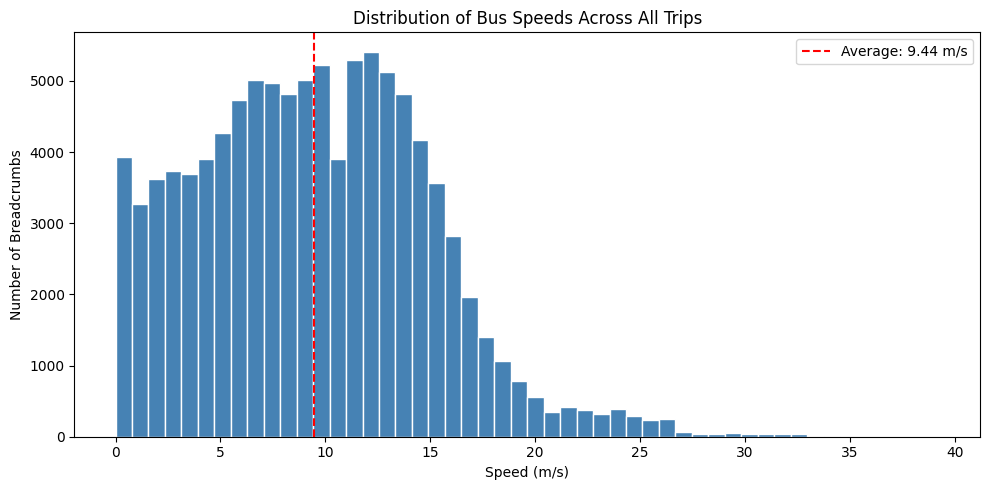

Total breadcrumbs analyzed: 100000
Average speed: 9.44 m/s
Max speed: 39.25 m/s


In [ ]:
# Additional Visualization 1
# Histogram of bus speeds across all breadcrumbs

import matplotlib.pyplot as plt

cur.execute("""
    SELECT speed
    FROM breadcrumb
    WHERE speed > 0 AND speed < 40
    LIMIT 100000;
""")
rows = cur.fetchall()
speeds = [row[0] for row in rows]

plt.figure(figsize=(10, 5))
plt.hist(speeds, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Speed (m/s)')
plt.ylabel('Number of Breadcrumbs')
plt.title('Distribution of Bus Speeds Across All Trips')
plt.axvline(x=sum(speeds)/len(speeds), color='red',
            linestyle='--', label=f'Average: {sum(speeds)/len(speeds):.2f} m/s')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total breadcrumbs analyzed: {len(speeds)}")
print(f"Average speed: {sum(speeds)/len(speeds):.2f} m/s")
print(f"Max speed: {max(speeds):.2f} m/s")

---

**Additional Visualization 2:**

[Describe the visualization and what it shows]

This bar chart shows the total number of passenger boardings per hour of the day. It helps us understand when buses are busiest throughout the day and identify peak travel times for Portland transit riders.

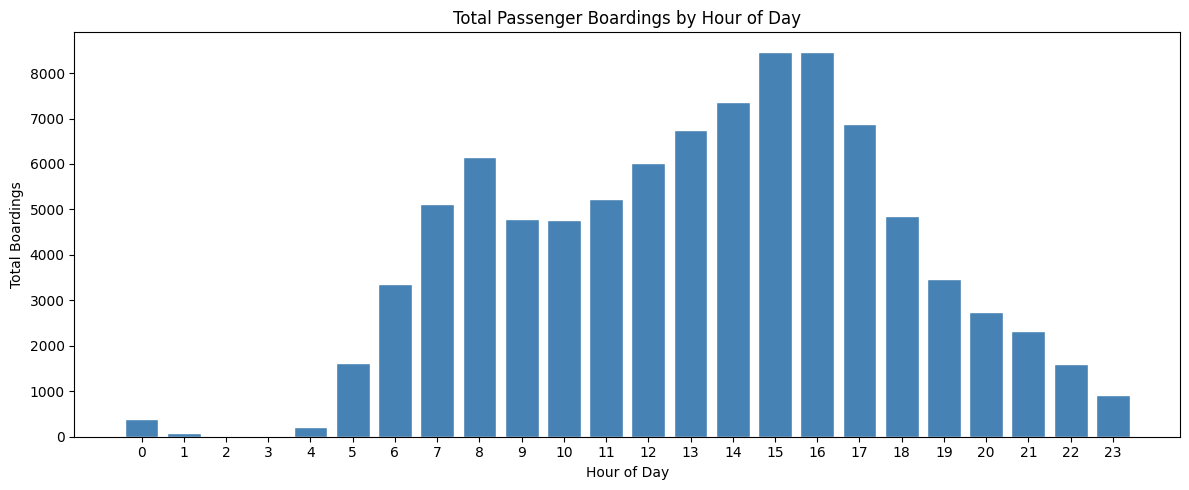

In [ ]:
# Additional Visualization 2
# Total boardings by hour of day

cur.execute("""
    SELECT EXTRACT(HOUR FROM arrive_time) AS hour,
           SUM(ons) AS total_boardings
    FROM stopevent
    WHERE ons > 0
    GROUP BY hour
    ORDER BY hour;
""")
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_hourly = pd.DataFrame(rows, columns=cols)

plt.figure(figsize=(12, 5))
plt.bar(df_hourly["hour"], df_hourly["total_boardings"],
        color='steelblue', edgecolor='white')
plt.xlabel('Hour of Day')
plt.ylabel('Total Boardings')
plt.title('Total Passenger Boardings by Hour of Day')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

---

**Additional Visualization 3:**

[Describe the visualization and what it shows]

This heatmap shows the average bus speed for each hour of the day and
each day of the week. It helps us see patterns in how fast buses move
at different times or example whether buses are slower during rush
hour due to traffic or faster late at night when roads are clear.


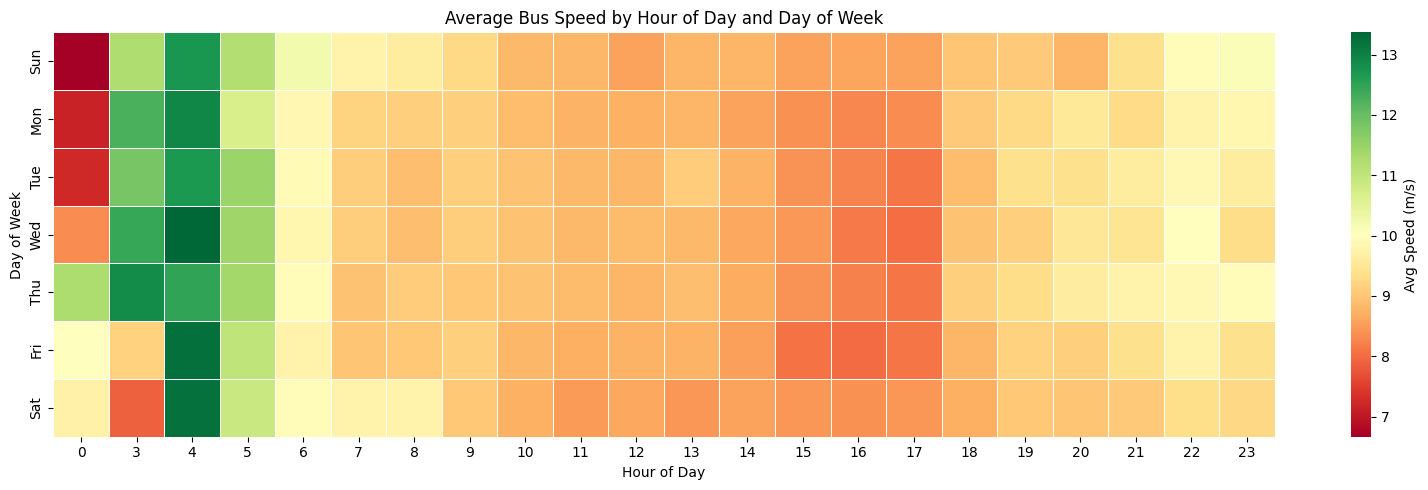

In [ ]:
# Additional Visualization 3
# Heatmap of average speed by hour of day and day of week

import numpy as np
import seaborn as sns

cur.execute("""
    SELECT
        EXTRACT(DOW FROM timestamp) AS day_of_week,
        EXTRACT(HOUR FROM timestamp) AS hour,
        AVG(speed) AS avg_speed
    FROM breadcrumb
    WHERE speed > 0
    GROUP BY day_of_week, hour
    ORDER BY day_of_week, hour;
""")
rows = cur.fetchall()
cols = [desc[0] for desc in cur.description]
df_heatmap = pd.DataFrame(rows, columns=cols)

# Pivot for heatmap
pivot = df_heatmap.pivot(index="day_of_week", columns="hour", values="avg_speed")
pivot.index = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap="RdYlGn", annot=False,
            linewidths=0.5, cbar_kws={"label": "Avg Speed (m/s)"})
plt.title("Average Bus Speed by Hour of Day and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

---


## 11. Reflections

Answer each reflection question thoughtfully. Write at least 2-3 sentences for each.

---

**Reflection 1:** Compare and contrast the processing of StopEvent data with the
processing of BreadCrumb data. Consider the format of the raw data, how it is fetched
and parsed, the types of validation and transformation required, and the structure of
the resulting database records. What was easier or harder about StopEvents compared to
BreadCrumbs?

**Your answer:**

StopEvent data was harder than BreadCrumb data because it came as HTML
instead of JSON so we had to parse it with BeautifulSoup. We also had to
convert Oregon State Plane coordinates to GPS which BreadCrumbs did not
need. BreadCrumbs were simpler but StopEvents have richer data like
passenger counts.

---

**Reflection 2:** In Part 3 we asked you to add new Python programs (`se_publisher.py`,
`se_analysis.py`, `se_backup.py`) for processing StopEvents, rather than modifying the
existing BreadCrumb programs. Could we instead have changed or augmented the existing
programs to handle both data types? What would the advantages and disadvantages of that
architectural choice be? Consider separation of concerns, code complexity, fault isolation,
and operational simplicity.

**Your answer:**

We could have combined everything into one program but separate programs were better. If one breaks the other keeps running. The code is also
cleaner since each program has one job. The only downside is more files
to manage.

---

**Reflection 3:** In this project, the StopEvent data and the BreadCrumb data share a
common key (`trip_number` / `EVENT_NO_TRIP`) that allows you to join the two tables and
produce richer analyses than either dataset alone could support. This is an example of
data integration. Referring to the dimensions of data integration discussed in the lecture
(time, space, relational), explain which dimension(s) connect the BreadCrumb and StopEvent
datasets and describe at least one challenge you encountered or anticipate when joining them.

**Your answer:**

The two datasets connect through the trip_number field which lets us join
GPS data with passenger data. The challenge we faced was that trip_number  in StopEvent was a small number while trip_id in BreadCrumb was a large
unique ID. We had to fix the publisher to extract the real trip ID from
the HTML.

---

**Reflection 4:** Data bias can affect the quality and fairness of conclusions drawn from
transit datasets. Identify at least two potential sources of bias in the combined
BreadCrumb and StopEvent data that could affect an analysis of passenger boarding patterns
across the TriMet system. For each, explain how the bias arises and how it might be
detected or mitigated.

**Your answer:**

One source of bias is that our data only covers 222 vehicles out of the
full TriMet fleet. These vehicles might be assigned to specific routes
so our boarding analysis may not represent all of Portland. We can detect
this by checking which routes are missing from our data and compare with
the full TriMet route list. To mitigate it we could combine data from
all teams or note which routes are not covered.

Another source of bias is that our data is only from January 2023 which
is winter. Ridership in winter is lower and different from summer because
of weather and school schedules. We can detect this by comparing our
numbers to TriMet's published ridership data for the same month. To
mitigate it we would need to collect data across different seasons.

---
